# Exercice Algorithme de SHor
Il existe Z qui agit sur l'état |1>, et ajoute une phase globale de $\pi$ dans ce cas.
$$ Z|1> = -|1> = e^{i\pi}|1>$$ 

Dans cet exercice nous allons factoriser 35 en effectuant une estiamtion de phase sur un circuit qui implemente 13y mod 35. L'exercice consiste à créer un circuit qui fait cela, et assez petit pour etre effectuer sur un ordio quantique.

L'algorithme de Shor n'a besoin de travailler que sur des états que nous pouvons atteindre en appliquant U à l'état de départ |1>. C'est à dire que nous pouvons utiliser le circuit Any qui a le comportement :
$$U|1> = |13>$$
$$UU|1> = |29>$$
$$UUU|1> = |27>$$
$$UUUU|1> = |1>$$

Pour rendre cela plus facile, on va transformer les 4 états différents, nous allons les coder sur deux qubits. 
$$|1> =  |00>$$
$$|13> = |01>$$
$$|29> = |10>$$
$$|27> = |11>$$

Cela revient à tricher , car pour tirer de l'optimisation faite, nous devons connaitre tous les états quer UY va affceter, ce qui signifie que nous devons calculer $ay \text{mod } N$ jusqu'a ce que nous revenions à 1, et cela reveins à dire que nous connaissons la période de $a^x  \text{mod } N$ et donc on ne peut obtenir que les facteurs den N.

Exercice 2a : créer un circuit qui effectue la transformation:
$$U|00> = |01>$$
$$U|01> = |10>$$
$$U|10>= |11>$$
$$U|11> = |00>$$
et est controlé par un autre qubit. Le circuit agira sur un registre à 2 qubits nommé cible et sera controlé par un autre registre à un seul qubit nommé controle. Vous devez affecter votre circuit fini à la varibale 'cu'

<IPython.core.display.Latex object>

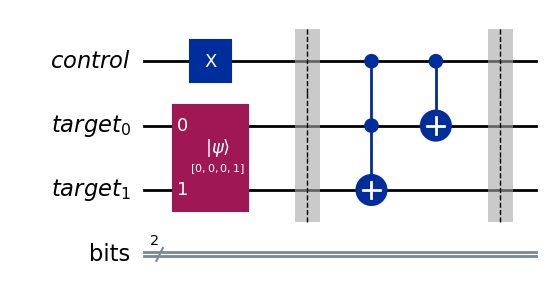

<IPython.core.display.Latex object>

In [173]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import Operator
from qiskit import QuantumRegister, ClassicalRegister
c = QuantumRegister(1, 'control')
t = QuantumRegister(2, 'target')
cr = ClassicalRegister(2,'bits')
cu = QuantumCircuit(c,t,cr, name="Controlled 13^x mod 35")
cu.x(0)
psi = [0,0,0,1]
cu.initialize(psi, [1,2])

sv = Statevector.from_instruction(cu)
display(sv.draw(output='latex'))
cu.barrier()

cu.ccx(c, t[0], t[1])
cu.cx(c, t[0])
cu.barrier()
# cu.measure([1,2], [0,1])

display(cu.draw("mpl"))


sv = Statevector.from_instruction(cu)
display(sv.draw(output='latex'))

In [174]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

aer = AerSimulator()
job = aer.run(cu, shots=1000).result()
result = job.get_counts()
display(result)

plot_histogram(result)

QiskitError: 'No counts for experiment "0"'

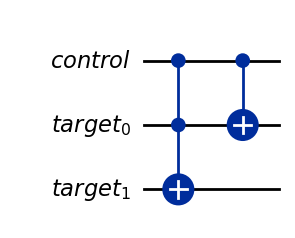

In [177]:
# circuit correspondant 
c = QuantumRegister(1, 'control')
t = QuantumRegister(2, 'target')
cu = QuantumCircuit(c,t, name="Controlled 13^x mod 35")

cu.ccx(c, t[0], t[1])
cu.cx(c, t[0])
display(cu.draw("mpl"))


Exercice 2b: creer un circuit equivalent à applqiuer deux fois U.

<IPython.core.display.Latex object>

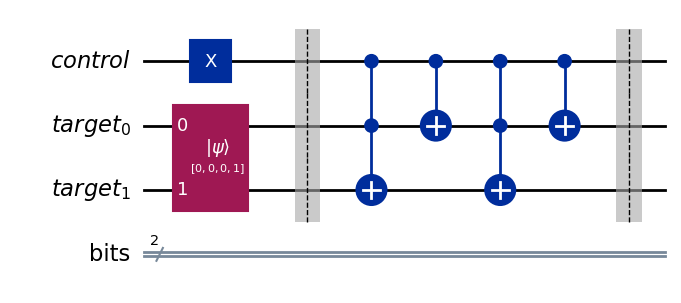

<IPython.core.display.Latex object>

In [176]:
c = QuantumRegister(1, 'control')
t = QuantumRegister(2, 'target')
cr = ClassicalRegister(2,'bits')
cu = QuantumCircuit(c,t,cr, name="Controlled 13^x mod 35")
cu.x(0)
psi = [0,0,0,1]
cu.initialize(psi, [1,2])

sv = Statevector.from_instruction(cu)
display(sv.draw(output='latex'))
cu.barrier()

cu.ccx(c, t[0], t[1])
cu.cx(c, t[0])
cu.ccx(c, t[0], t[1])
cu.cx(c, t[0])

cu.barrier()
# cu.measure([1,2], [0,1])

display(cu.draw("mpl"))


sv = Statevector.from_instruction(cu)
display(sv.draw(output='latex'))


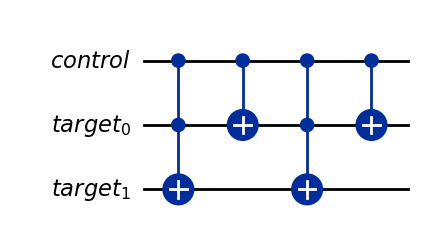

In [178]:
# Circuit correspondant 
c = QuantumRegister(1, 'control')
t = QuantumRegister(2, 'target')
cu2 = QuantumCircuit(c, t)

cu2.ccx(c, t[0], t[1])
cu2.cx(c, t[0])
cu2.ccx(c, t[0], t[1])
cu2.cx(c, t[0])

display(cu2.draw("mpl"))


Exercice 2c:


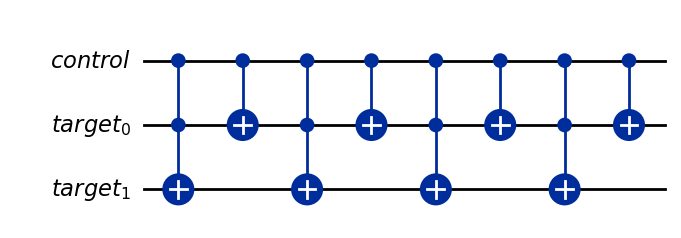

In [179]:
c = QuantumRegister(1, 'control')
t = QuantumRegister(2, 'target')
cu4 = QuantumCircuit(c, t)

cu4 = cu2.compose(cu2)

display(cu4.draw("mpl"))

Exercice 2 final:
creer un circuit qui execute les portes U controlés, qiui seront utilisés dans l'initiation et la transfomée de fourier quantique inverse. Plus formellement, on veut un cricuit:
$$ CU_{c_Ot}CU_{c_1t}^2CU_{c_2t}^4$$

$c_0, c_1, c_2$ les trois qubits du registre comptage, t le registre cible et U la matrice défini avant.
La notation, $CU_{ab}$ signifie que CU est controlé par a et b. Le cir(cuit ne peut contenir que des portes CNOT et un seul qubit U-Gate.

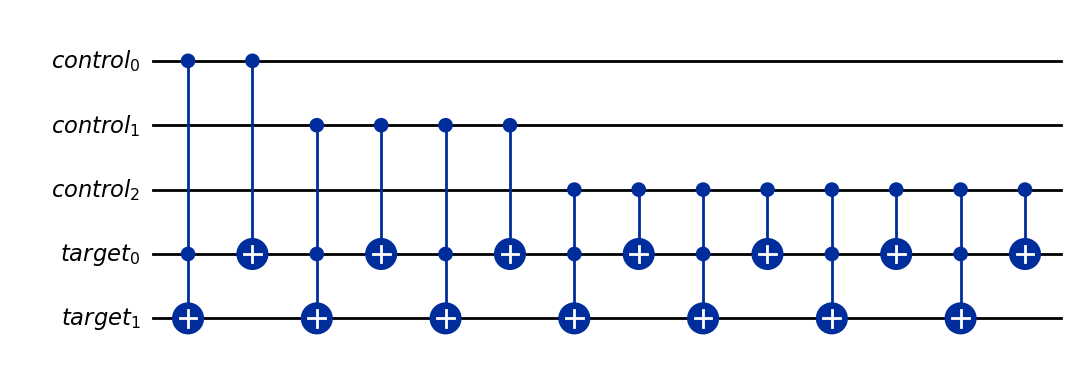

In [180]:
cqr = QuantumRegister(3, 'control')
tqr = QuantumRegister(2, 'target')
cux = QuantumCircuit(cqr, tqr)
solutions = [cu, cu2, cu4]
for i in range(3):
    cux = cux.compose(solutions[i], [cqr[i], tqr[0], tqr[1]])
cux.draw('mpl')

Utilisation du circuit pour factoriser 35

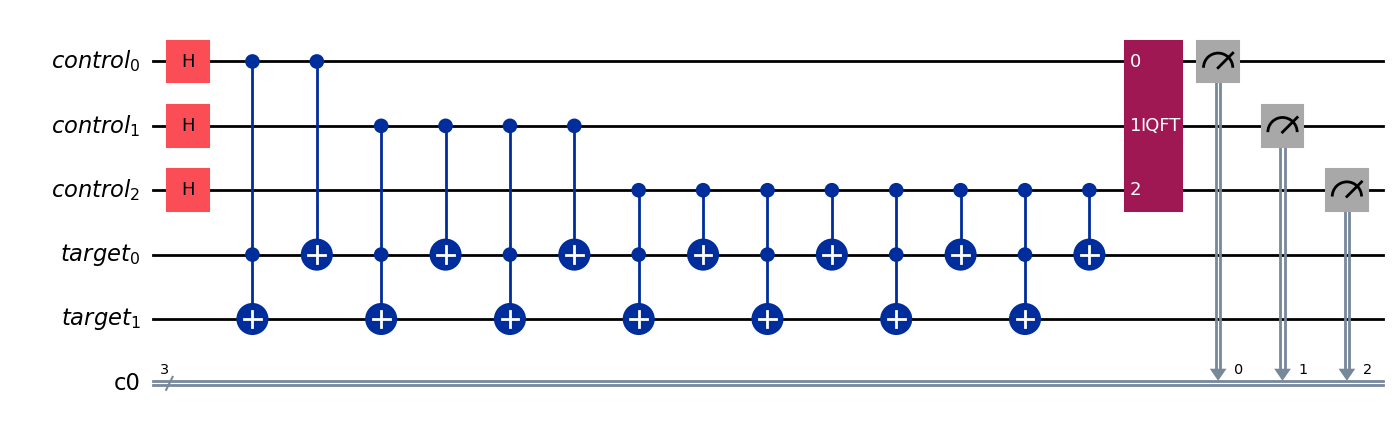

In [181]:
from qiskit.circuit.library import QFT
from qiskit import ClassicalRegister
# Créer l'objet circuit
cr = ClassicalRegister(3)
shor_circuit = QuantumCircuit(cqr, tqr, cr)

# Initialiser les qubits
shor_circuit.h(cqr)

# Ajoutez votre circuit
shor_circuit = shor_circuit.compose(cux)

# Effectuer le QFT inverse et extraire la sortie
shor_circuit.append(QFT(3, inverse=True), cqr)
shor_circuit.measure(cqr, cr)
shor_circuit.draw('mpl')

In [184]:
from qiskit import transpile
from qiskit.visualization import plot_histogram
qasm_sim = AerSimulator()
tqc = transpile(shor_circuit, basis_gates=['u', 'cx'], optimization_level=3)
print(f"circuit depth: {tqc.depth()}")
print(f"Circuit contains {tqc.count_ops()['cx']} CNOTs")

/Users/Quentin/Documents/applications/PythonIDE/path_env/quantum_env/lib/python3.8/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


circuit depth: 77
Circuit contains 41 CNOTs


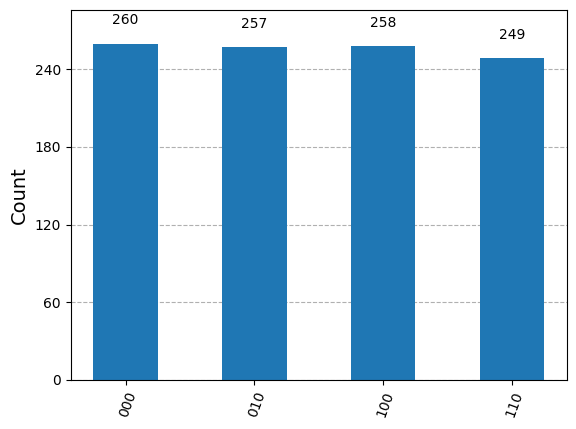

In [185]:
counts = qasm_sim.run(tqc).result().get_counts()
plot_histogram(counts)

In [186]:
from fractions import Fraction
n = 3  # n est le nombre de qubits dans notre registre de "comptage"
# Parcourez chaque chaîne de mesure
for measurement in counts.keys():
    # Convertissez la chaîne binaire en 'int' et divisez par 2^n
    decimal = int(measurement, 2)/2**n
    # Utilisez l'algorithme des fractions continues pour convertir en forme a/b
    print(Fraction(decimal).limit_denominator())

1/2
3/4
0
1/4


In [187]:
13**4 % 35

1

In [188]:
from math import gcd # Greatest common divisor
for x in [-1, 1]:
    print(f"Guessed factor: {gcd(13**(4//2)+x, 35)}")

Guessed factor: 7
Guessed factor: 5
